In [47]:

import re
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import libpysal
from scipy import sparse
from scipy.stats import norm
from esda.moran import Moran
from esda.getisord import G_Local
from pathlib import Path
from collections import defaultdict
from scipy.ndimage import gaussian_filter1d
import matplotlib.patheffects as pe
 
OUT = Path("/Users/cyberhbliu/Desktop/PERSONAL/2026portfolio/crash") / "crash_outputs"
OUT.mkdir(exist_ok=True)
GRAPH_FILE = OUT / "philadelphia_drive_2272.graphml"   # pinned network
SEED = 2272
N_SIMS = 999
SNAP_FLAG_FT = 100     # FLAG (never drop) crashes snapping beyond this (US ft)
MIN_SEG_M = 60         # min segment length (meters) for ranked tables only
GI_ALPHA = 0.05 

In [2]:
CRASH_URL = ("https://raw.githubusercontent.com/cyber-hbliu/"
             "Urban-Street-Networks-and-Interactive-Web-Maps/"
             "2c1730f57912fb26c5d2aa914d8ede260e8d75cd/"
             "data/collision_crash_2020_2024.csv")
HIN_PATH = "TK"        # 2025 High Injury Network GeoJSON (OpenDataPhilly) or
                       # local path — port the loader from crash_index_hin.py
HIN_BUFFER_FT = 100    # Roosevelt Blvd lesson: 50 ft misses parallel edges
 
ox.settings.use_cache = True
ox.settings.cache_folder = Path.home() / ".osmnx_cache"

In [3]:
INK, BONE, FAINT = "#0b0b0e", "#ffffff", "#26262e"
DIM, TEAL, PULSE, GOLD = "#76a5af", "#00b3b3", "#e04996", "#ffd862"
CMAP = mcolors.LinearSegmentedColormap.from_list(
    "voltage", ["#0b0b0e", "#7c49ab", "#e04996", "#ffd862"])
plt.rcParams.update({
    "figure.facecolor": INK, "axes.facecolor": INK, "savefig.facecolor": INK,
    "text.color": BONE, "axes.edgecolor": DIM, "axes.labelcolor": BONE,
    "xtick.color": DIM, "ytick.color": DIM, "font.family": "monospace",
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False})

In [4]:
if GRAPH_FILE.exists():
    G = ox.load_graphml(GRAPH_FILE)
    print(f"Loaded pinned network: {GRAPH_FILE.name}")
else:
    G = ox.graph_from_place("Philadelphia, Pennsylvania, USA",
                            network_type="drive")
    G = ox.project_graph(G, to_crs="EPSG:2272")
    G = ox.convert.to_undirected(G)      # two-way street = one edge
    ox.save_graphml(G, GRAPH_FILE)
    print(f"Built and pinned network ({pd.Timestamp.now():%Y-%m-%d}); "
          f"record this OSM snapshot date in the writeup.")
 
edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

Loaded pinned network: philadelphia_drive_2272.graphml


In [5]:
assert edges.crs.to_epsg() == 2272
 
def first_str(v):
    """OSM tags arrive as str, list, or stringified list. Take the first."""
    s = str(v)
    m = re.match(r"\[?'?([^',\]]+)", s)
    return m.group(1).strip() if m else s
 
edges["name"] = edges["name"].apply(first_str)
edges["hwy"] = edges["highway"].apply(first_str)
edges["maxspeed"] = edges.get("maxspeed", pd.Series(index=edges.index)).apply(first_str)
edges["limited_access"] = edges["hwy"].str.contains("motorway")
n_edges = len(edges)
print(f"Network: {n_edges} undirected segments, "
      f"{edges['length'].sum()/1609.34:.0f} mi total")

Network: 41497 undirected segments, 2823 mi total


In [6]:
raw = pd.read_csv(CRASH_URL) 

comp = raw.assign(geocoded=raw[["dec_latitude", "dec_longitude"]]
                  .notna().all(axis=1)) \
          .groupby("crash_year") \
          .agg(total=("geocoded", "size"), geocoded=("geocoded", "sum"))
comp["pct"] = 100 * comp["geocoded"] / comp["total"]
print("\nGeocoding completeness by year (cite this before claiming a trend):")
print(comp.to_string())


Geocoding completeness by year (cite this before claiming a trend):
            total  geocoded    pct
crash_year                        
2020         8110      8110  100.0
2021         8458      8458  100.0
2022         6911      6911  100.0
2023         6904      6904  100.0
2024         5920      5920  100.0


/var/folders/rp/0t393qy94k3_n1h8yry822hr0000gn/T/ipykernel_6206/2846063219.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  comp = raw.assign(geocoded=raw[["dec_latitude", "dec_longitude"]]


In [7]:
crash = raw.dropna(subset=["dec_latitude", "dec_longitude"]).copy()
crash["fatal"] = crash["fatal_count"] > 0
crash["ksi"] = (crash["fatal_count"] + crash["susp_serious_inj_count"]) > 0
crash_geo = gpd.GeoDataFrame(
    crash, geometry=gpd.points_from_xy(crash["dec_longitude"],
                                       crash["dec_latitude"]),
    crs="EPSG:4326").to_crs(epsg=2272)

In [8]:
crash

,X,Y,objectid,crn,arrival_tm,automobile_count,belted_death_count,belted_susp_serious_inj_count,bicycle_count,bicycle_death_count,...,unsignalized_int,urban,vehicle_failure,vehicle_towed,vulnerable_road_user,vulnerable_road_user_fatal,wet_road,work_zone,young_driver,ksi
0,-8.376536e+06,4.860532e+06,1,2020007295,NaN,4,0,0,0,0,...,0,1,0,1,0,0,0,0,0,False
1,-8.379867e+06,4.862518e+06,2,2020066105,1742.0,1,0,0,0,0,...,1,1,0,1,0,0,0,0,1,False
2,-8.380039e+06,4.862389e+06,3,2020067671,NaN,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,False
3,-8.375669e+06,4.857235e+06,4,2020086583,458.0,1,0,0,0,0,...,0,1,0,1,0,0,1,0,0,False
4,-8.378072e+06,4.848003e+06,5,2021029069,2355.0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36298,-8.351862e+06,4.872284e+06,36299,2025026066,50.0,2,0,0,0,0,...,0,1,0,1,0,0,0,0,0,False
36299,-8.368214e+06,4.855029e+06,36300,2025027435,510.0,1,0,0,0,0,...,0,1,0,0,1,0,0,0,0,False
36300,-8.362016e+06,4.870541e+06,36301,2025012535,NaN,1,0,0,0,0,...,1,1,0,1,0,0,0,0,0,False
36301,-8.365700e+06,4.864984e+06,36302,2025043500,2031.0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,True


In [9]:
ne, snap_dist = ox.distance.nearest_edges(
    G, X=crash_geo.geometry.x.values, Y=crash_geo.geometry.y.values,
    return_dist=True)
crash_geo[["u", "v", "key"]] = pd.DataFrame(list(ne), index=crash_geo.index)
crash_geo["snap_ft"] = snap_dist   # graph CRS is feet
 
for thr in (100, 300, 900):
    print(f"snap > {thr} ft: {(crash_geo['snap_ft'] > thr).sum()} crashes")

snap > 100 ft: 350 crashes
snap > 300 ft: 241 crashes
snap > 900 ft: 57 crashes


In [10]:
crash_geo["long_snap"] = crash_geo["snap_ft"] > SNAP_FLAG_FT
print(f"All {len(crash_geo)} crashes retained "
      f"(fatal {crash_geo['fatal'].sum()}, KSI {crash_geo['ksi'].sum()}); "
      f"{crash_geo['long_snap'].sum()} flagged as long-snap "
      f"(> {SNAP_FLAG_FT} ft).")

All 36303 crashes retained (fatal 620, KSI 2399); 350 flagged as long-snap (> 100 ft).


In [11]:
long = crash_geo.loc[crash_geo["long_snap"]]
xy = long.geometry.apply(lambda g: (round(g.x, -1), round(g.y, -1)))
print("\nMost repeated long-snap coordinates (repeats = centroid or "
      "facility defaults, e.g. stadium lots / airport):")
print(xy.value_counts().head(5).to_string())


Most repeated long-snap coordinates (repeats = centroid or facility defaults, e.g. stadium lots / airport):
geometry
(2730390.0, 301690.0)    20
(2712800.0, 277850.0)    18
(2678560.0, 284410.0)     9
(2678580.0, 284430.0)     8
(2712350.0, 278170.0)     7


In [12]:
fl = long.loc[long["fatal"],
              ["crash_year", "dec_latitude", "dec_longitude", "snap_ft"]]
print(f"\nFatal crashes snapping beyond {SNAP_FLAG_FT} ft — "
      f"verify each by hand:")
print(fl.to_string())


Fatal crashes snapping beyond 100 ft — verify each by hand:
       crash_year  dec_latitude  dec_longitude     snap_ft
792          2024     40.080893     -75.202667  331.797760
3800         2020     39.969647     -75.261739  803.346994
24612        2023     40.096473     -74.959034  394.887669


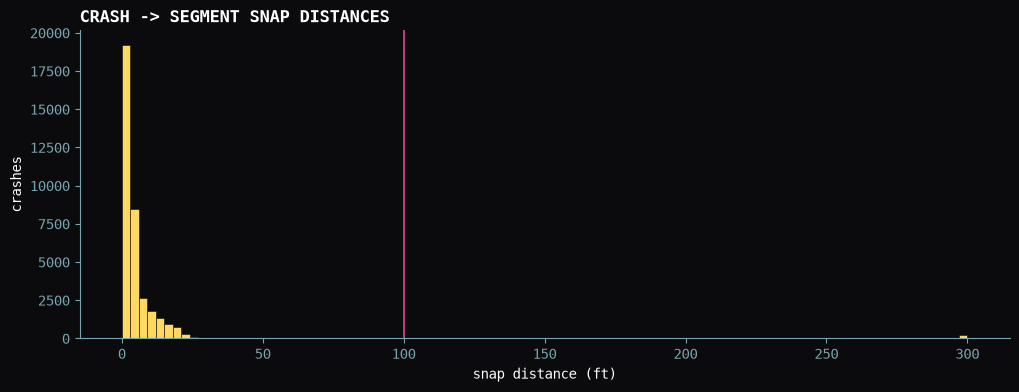

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(np.clip(crash_geo["snap_ft"], 0, 300), bins=100, color=GOLD,
        ec=INK, lw=0.4)
ax.axvline(SNAP_FLAG_FT, color=PULSE, lw=1.2)
ax.set_xlabel("snap distance (ft)"); ax.set_ylabel("crashes")
ax.set_title("CRASH -> SEGMENT SNAP DISTANCES", loc="left")
fig.savefig(OUT / "snap_distances.png", dpi=400, bbox_inches="tight")

In [15]:
if isinstance(edges.index, pd.MultiIndex):
    edges = edges.reset_index()
DERIVED = ["crash_count", "fatal_cnt", "ksi_cnt", "long_snap_cnt",
           "crash_index", "fatal_index", "ksi_index",
           "crash_dens", "fatal_dens", "ksi_dens",
           "hot_crash", "hot_fatal", "hot_ksi", "on_hin"]
edges = edges.drop(columns=DERIVED, errors="ignore")
 

In [16]:
counts = crash_geo.groupby(["u", "v", "key"]).agg(
    crash_count=("fatal", "size"),
    fatal_cnt=("fatal", "sum"),
    ksi_cnt=("ksi", "sum"),
    long_snap_cnt=("long_snap", "sum")).reset_index()  # fragile snaps visible
edges = edges.merge(counts, on=["u", "v", "key"], how="left")
for c in ["crash_count", "fatal_cnt", "ksi_cnt", "long_snap_cnt"]:
    edges[c] = edges[c].fillna(0)
 
for cnt, idx in [("crash_count", "crash_index"),
                 ("fatal_cnt", "fatal_index"),
                 ("ksi_cnt", "ksi_index")]:
    m = edges[cnt] > 0
    logd = np.log10(edges.loc[m, cnt] / edges.loc[m, "length"])
    edges.loc[m, idx] = (logd - logd.min()) / (logd.max() - logd.min())

In [17]:
med_cb = edges["crash_index"].median()
below_med = (edges["crash_index"] < med_cb).fillna(False).values
 
lengths = edges["length"].values
total_len = lengths.sum()
n_crash = len(crash_geo)
n_fatal = int(crash_geo["fatal"].sum())
n_ksi = int(crash_geo["ksi"].sum())

top 12% of network length carries 71.8% of all crashes
top 12% of network length carries 100.0% of KSI crashes
top 12% of network length carries 100.0% of fatal crashes


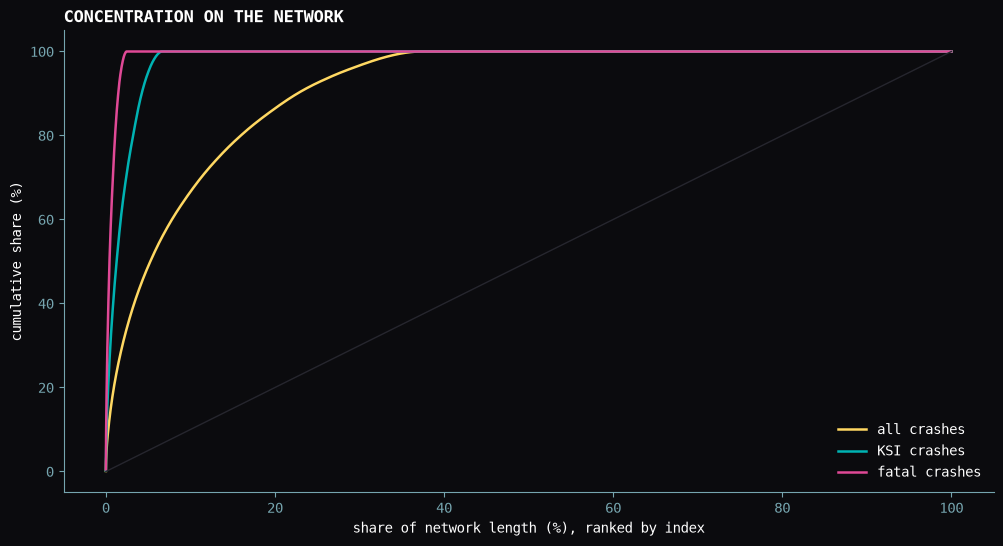

In [18]:
#concentration curves
fig, ax = plt.subplots(figsize=(12, 6))
for cnt, idx, color, label in [
        ("crash_count", "crash_index", GOLD, "all crashes"),
        ("ksi_cnt", "ksi_index", TEAL, "KSI crashes"),
        ("fatal_cnt", "fatal_index", PULSE, "fatal crashes")]:
    d = edges.sort_values(idx, ascending=False)
    cl = d["length"].cumsum() / total_len * 100
    cc = d[cnt].cumsum() / d[cnt].sum() * 100
    ax.plot(cl, cc, color=color, label=label, lw=1.8)
    k = np.searchsorted(cl.values, 12)
    print(f"top 12% of network length carries {cc.iloc[k]:.1f}% of {label}")
ax.plot([0, 100], [0, 100], color=FAINT, lw=1)
ax.set_xlabel("share of network length (%), ranked by index")
ax.set_ylabel("cumulative share (%)")
ax.set_title("CONCENTRATION ON THE NETWORK", loc="left")
ax.legend(frameon=False)
fig.savefig(OUT / "concentration_curves.png", dpi=400, bbox_inches="tight")

In [19]:
d = edges.sort_values("crash_index", ascending=False)
cl = d["length"].cumsum() / total_len * 100
cum_c = d["crash_count"].cumsum().values
cum_f = d["fatal_cnt"].cumsum().values
cum_k = d["ksi_cnt"].cumsum().values
print("\nVolume-targeting capture (rank by crash index):")
for pct in (1, 5, 12):
    k = np.searchsorted(cl.values, pct)
    print(f"  top {pct:>2}% of length: {cum_c[k]/n_crash*100:5.1f}% of crashes"
          f" | {cum_f[k]/n_fatal*100:5.1f}% of fatal"
          f" | {cum_k[k]/n_ksi*100:5.1f}% of KSI"
          f"   (compare fatal vs crash share: gap = deviation from random)")
 


Volume-targeting capture (rank by crash index):
  top  1% of length:  20.7% of crashes |  22.3% of fatal |  22.7% of KSI   (compare fatal vs crash share: gap = deviation from random)
  top  5% of length:  48.9% of crashes |  52.4% of fatal |  51.9% of KSI   (compare fatal vs crash share: gap = deviation from random)
  top 12% of length:  71.8% of crashes |  73.9% of fatal |  73.8% of KSI   (compare fatal vs crash share: gap = deviation from random)


In [20]:
node_edges = defaultdict(list)
for i, (u, v) in enumerate(zip(edges["u"], edges["v"])):
    node_edges[u].append(i); node_edges[v].append(i)
nbrs = {i: set() for i in range(n_edges)}
for ids in node_edges.values():
    for a in ids:
        nbrs[a].update(ids)
 
w = libpysal.weights.W({i: [j for j in nb if j != i]
                        for i, nb in nbrs.items()})
if w.islands:
    print(f"WARNING: {len(w.islands)} island segments (disconnected "
          f"components). Gi* is degenerate there; they stay non-hotspot.")
w.transform = "r"

In [21]:
rows, cols = [], []
for i, nb in nbrs.items():
    for j in nb:               # nb includes i itself via shared-node sets
        rows.append(i); cols.append(j)
    if i not in nb:
        rows.append(i); cols.append(i)
W_star = sparse.csr_matrix((np.ones(len(rows)), (rows, cols)),
                           shape=(n_edges, n_edges))
wi = np.asarray(W_star.sum(axis=1)).ravel() 

In [23]:
def gi_star_z(x):
    """Analytical Gi* z-scores (Ord & Getis 1995), binary weights, vectorized."""
    n = len(x)
    xbar, s = x.mean(), x.std(ddof=0)
    lag = W_star @ x
    denom = s * np.sqrt((n * wi - wi ** 2) / (n - 1))
    denom[denom == 0] = np.inf
    return (lag - xbar * wi) / denom
 
def bh_hotspots(z, alpha=GI_ALPHA):
    """One-sided (high) p-values + Benjamini–Hochberg FDR -> hotspot mask."""
    p = norm.sf(z)
    m = len(p)
    order = np.argsort(p)
    thresh = alpha * (np.arange(1, m + 1)) / m
    passed = p[order] <= thresh
    k = np.max(np.nonzero(passed)[0]) + 1 if passed.any() else 0
    mask = np.zeros(m, dtype=bool)
    mask[order[:k]] = True
    return mask
 
edges["crash_dens"] = edges["crash_count"] / edges["length"]
edges["fatal_dens"] = edges["fatal_cnt"] / edges["length"]
edges["ksi_dens"] = edges["ksi_cnt"] / edges["length"]
 
for col, label in [("crash_dens", "crash"), ("fatal_dens", "fatal"),
                   ("ksi_dens", "KSI")]:
    mi = Moran(edges[col].values, w, permutations=999)
    print(f"Moran's I ({label} density): I={mi.I:.3f}, p={mi.p_sim:.4f}  "
          f"(z={mi.z_sim:.3f}, E[I]={mi.EI:.3f}, Var[I]={mi.VI_norm:.4f})")

Moran's I (crash density): I=0.051, p=0.0010  (z=16.002, E[I]=-0.000, Var[I]=0.0000)
Moran's I (fatal density): I=0.013, p=0.0100  (z=3.617, E[I]=-0.000, Var[I]=0.0000)
Moran's I (KSI density): I=0.035, p=0.0010  (z=10.233, E[I]=-0.000, Var[I]=0.0000)


In [24]:
z_crash = gi_star_z(edges["crash_dens"].values)
z_fatal = gi_star_z(edges["fatal_dens"].values)
z_ksi = gi_star_z(edges["ksi_dens"].values)
edges["hot_crash"] = bh_hotspots(z_crash)
edges["hot_fatal"] = bh_hotspots(z_fatal)
edges["hot_ksi"] = bh_hotspots(z_ksi)

In [25]:
edges

,u,v,key,osmid,highway,lanes,maxspeed,name,oneway,service,...,long_snap_cnt,crash_index,fatal_index,ksi_index,crash_dens,fatal_dens,ksi_dens,hot_crash,hot_fatal,hot_ksi
0,109726936,109992543,0,43226669,primary,2,25 mph,Germantown Avenue,False,disused_tram,...,0.0,0.575007,NaN,NaN,0.072630,0.000000,0.000000,False,False,False
1,109726936,109992535,0,43226669,primary,2,25 mph,Germantown Avenue,False,disused_tram,...,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,False,False,False
2,109726936,109726940,0,12108955,residential,NaN,nan,Brunner Street,True,NaN,...,0.0,0.305245,NaN,NaN,0.005735,0.000000,0.000000,False,False,False
3,109992543,109992553,0,43226669,primary,2,25 mph,Germantown Avenue,False,disused_tram,...,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,False,False,False
4,109992543,110170309,0,12153079,residential,NaN,nan,Saint Paul Street,True,NaN,...,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41492,11102765428,11102765435,0,"[686713194, 1196533805, 1210561690]",secondary,2,25 mph,Martin Luther King Junior Drive,False,NaN,...,0.0,0.261732,0.250954,0.336561,0.003808,0.001904,0.003808,False,False,False
41493,11752443546,13114963990,0,1265089771,residential,NaN,nan,nan,False,NaN,...,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,False,False,False
41494,11752443546,13114963996,0,1426689758,residential,NaN,nan,nan,False,NaN,...,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,False,False,False
41495,13114963990,13114963991,0,1426689757,residential,NaN,nan,nan,False,NaN,...,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,False,False,False


In [26]:
def jaccard(a, b):
    u = (a | b).sum()
    return (a & b).sum() / u if u else np.nan
 
obs_jac = jaccard(edges["hot_crash"].values, edges["hot_fatal"].values)
print(f"\nGi* + BH-FDR hotspots: crash {edges['hot_crash'].sum()}, "
      f"fatal {edges['hot_fatal'].sum()}, KSI {edges['hot_ksi'].sum()}; "
      f"crash∩fatal Jaccard = {obs_jac:.3f}")


Gi* + BH-FDR hotspots: crash 669, fatal 467, KSI 674; crash∩fatal Jaccard = 0.107


In [27]:
wb = libpysal.weights.W(w.neighbors, silence_warnings=True)
wb.transform = "b"
for col, lbl in [("crash_dens", "crash"), ("fatal_dens", "fatal")]:
    gi = G_Local(edges[col].values, wb, star=True, permutations=999, seed=SEED)
    n_hot = int(((gi.Zs > 1.96) & (gi.p_sim < 0.05)).sum())
    print(f"esda cross-check ({lbl}): {n_hot} hotspots under "
          f"z>1.96 & p_sim<0.05 (uncorrected)")

esda cross-check (crash): 318 hotspots under z>1.96 & p_sim<0.05 (uncorrected)
esda cross-check (fatal): 295 hotspots under z>1.96 & p_sim<0.05 (uncorrected)


In [ ]:
rng = np.random.default_rng(SEED)
crash_edge = crash_geo.set_index(["u", "v", "key"]).index.map(
    pd.Series(np.arange(n_edges),
              index=pd.MultiIndex.from_frame(edges[["u", "v", "key"]]))
).values
assert not np.isnan(crash_edge.astype(float)).any(), \
    "some crashes map to no edge row — edges/crash_geo out of sync, rerun 1-4"
crash_edge = crash_edge.astype(int)
crash_year = crash_geo["crash_year"].values
years = np.sort(crash_geo["crash_year"].unique())

In [29]:
fatal_mask = crash_geo["fatal"].values

In [30]:
def five_stats(is_fatal, on_hin=None):
    """Compute S1, S2, S3, S4 (and S5 if HIN present) for a fatal labeling."""
    fc = np.bincount(crash_edge[is_fatal], minlength=n_edges).astype(float)
    hit = fc > 0
    s1 = lengths[hit].sum() / total_len * 100                    # length share
    s2 = (hit & below_med).sum() / hit.sum() * 100               # quiet share
    dens = np.where(hit, fc / lengths, 0.0)
    s3 = jaccard(edges["hot_crash"].values, bh_hotspots(gi_star_z(dens)))
    seg_yr = {y: set(np.unique(crash_edge[is_fatal & (crash_year == y)]))
              for y in years}
    rep_num = sum(len(seg_yr[y] & seg_yr[y2])
                  for y, y2 in zip(years[:-1], years[1:]))
    rep_den = sum(len(seg_yr[y]) for y in years[:-1])
    s4 = 100 * rep_num / rep_den if rep_den else np.nan          # repeat rate
    s5 = 100 * on_hin[is_fatal].mean() if on_hin is not None else np.nan
    return s1, s2, s3, s4, s5

In [31]:
on_hin = None
try:
    hin = gpd.read_file(HIN_PATH).to_crs(epsg=2272)
    hin_buf = hin.buffer(HIN_BUFFER_FT).union_all()
    on_hin = crash_geo.within(hin_buf).values
    edges["on_hin"] = gpd.GeoSeries(edges.geometry).intersects(hin_buf).values
    hin_len_pct = lengths[edges["on_hin"].values].sum() / total_len * 100
    print(f"\nHIN loaded: covers {hin_len_pct:.1f}% of network length; "
          f"captures {100*on_hin[fatal_mask].mean():.1f}% of fatal and "
          f"{100*on_hin[crash_geo['ksi'].values].mean():.1f}% of KSI crashes "
          f"(city claim: ~12% of streets, 80% of KSI).")
except Exception as e:
    print(f"\nHIN skipped ({e}). Set HIN_PATH to run the S5 audit.")
 
obs = five_stats(fatal_mask, on_hin)
null = np.array([five_stats(
    np.isin(np.arange(n_crash),
            rng.choice(n_crash, size=n_fatal, replace=False)), on_hin)
    for _ in range(N_SIMS)])
 
stat_names = ["S1 fatal-bearing length share (%)",
              "S2 fatal share on low-crash streets (%)",
              "S3 crash-vs-fatal hotspot Jaccard",
              "S4 year-over-year repeat rate (%)",
              "S5 HIN capture of fatal crashes (%)"]
print("\n=== OBSERVED vs NULL (fatal labels random among crashes) ===")
for k, name in enumerate(stat_names):
    if np.isnan(obs[k]):
        continue
    nk = null[:, k]
    extreme = np.sum(np.abs(nk - nk.mean()) >= np.abs(obs[k] - nk.mean()))
    p = (extreme + 1) / (N_SIMS + 1)
    p_str = f"p<={1/(N_SIMS+1):.3f}" if extreme == 0 else f"p={p:.3f}"
    print(f"{name}: observed {obs[k]:.2f} | null {nk.mean():.2f} "
          f"[{np.percentile(nk, 2.5):.2f}, {np.percentile(nk, 97.5):.2f}] "
          f"| {p_str}")


HIN skipped (TK: No such file or directory). Set HIN_PATH to run the S5 audit.

=== OBSERVED vs NULL (fatal labels random among crashes) ===
S1 fatal-bearing length share (%): observed 2.40 | null 2.04 [1.87, 2.22] | p<=0.001
S2 fatal share on low-crash streets (%): observed 25.00 | null 26.94 [23.53, 30.49] | p=0.293
S3 crash-vs-fatal hotspot Jaccard: observed 0.11 | null 0.13 [0.08, 0.19] | p=0.360
S4 year-over-year repeat rate (%): observed 5.33 | null 1.88 [0.78, 3.14] | p<=0.001


In [32]:
ok = ~crash_geo["long_snap"].values
for lbl, mask in [("all crashes    ", fatal_mask),
                  ("excl long snaps", fatal_mask & ok)]:
    fc = np.bincount(crash_edge[mask], minlength=n_edges).astype(float)
    hit = fc > 0
    print(f"sensitivity [{lbl}]: fatal-bearing length "
          f"{lengths[hit].sum()/total_len*100:.2f}% | low-crash share "
          f"{(hit & below_med).sum()/hit.sum()*100:.1f}%")

sensitivity [all crashes    ]: fatal-bearing length 2.40% | low-crash share 25.0%
sensitivity [excl long snaps]: fatal-bearing length 2.40% | low-crash share 25.0%


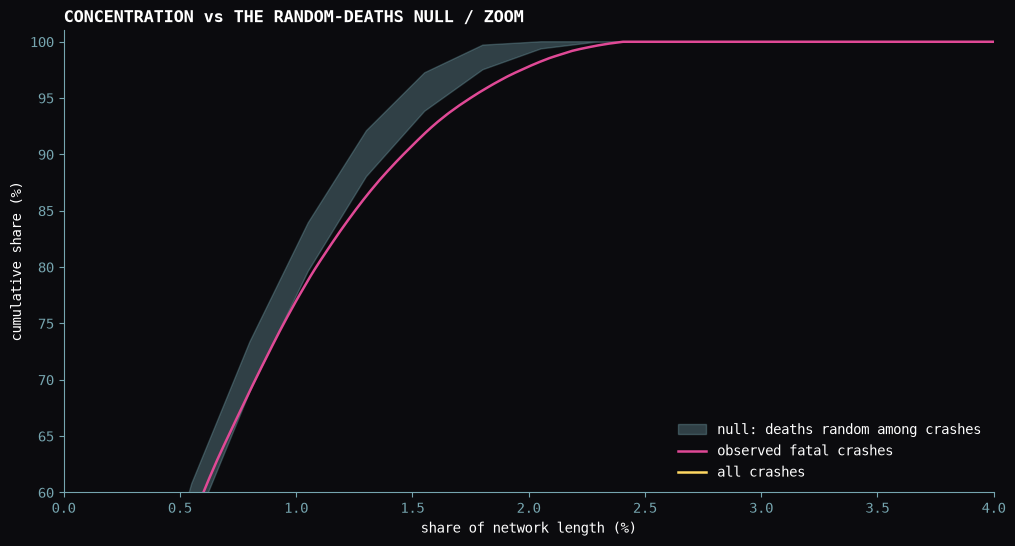

In [33]:
#concentration null envelope
d = edges.sort_values("fatal_index", ascending=False)
grid = np.linspace(0.05, 100, 400)
null_curves = np.empty((200, len(grid)))
for s in range(200):
    pick = rng.choice(crash_edge, size=n_fatal, replace=False)
    fc = np.bincount(pick, minlength=n_edges).astype(float)
    m = fc > 0
    logd = np.full(n_edges, -np.inf)
    logd[m] = np.log10(fc[m] / lengths[m])
    order = np.argsort(-logd)
    null_curves[s] = np.interp(grid,
                               lengths[order].cumsum() / total_len * 100,
                               fc[order].cumsum() / n_fatal * 100)
fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(grid, np.percentile(null_curves, 2.5, axis=0),
                np.percentile(null_curves, 97.5, axis=0),
                color=DIM, alpha=0.35, label="null: deaths random among crashes")
ax.plot(d["length"].cumsum() / total_len * 100,
        d["fatal_cnt"].cumsum() / n_fatal * 100,
        color=PULSE, lw=1.8, label="observed fatal crashes")
d2 = edges.sort_values("crash_index", ascending=False)
ax.plot(d2["length"].cumsum() / total_len * 100,
        d2["crash_count"].cumsum() / d2["crash_count"].sum() * 100,
        color=GOLD, lw=1.8, label="all crashes")
ax.plot([0, 100], [0, 100], color=FAINT, lw=1)
ax.set_xlim(0, 4); ax.set_ylim(60, 101)
ax.set_xlabel("share of network length (%)"); ax.set_ylabel("cumulative share (%)")
ax.set_title("CONCENTRATION vs THE RANDOM-DEATHS NULL / ZOOM", loc="left")
ax.legend(frameon=False, loc="lower right")
fig.savefig(OUT / "concentration_null_zoom.png", dpi=400, bbox_inches="tight")

In [34]:
by_class = crash_geo.merge(
    edges[["u", "v", "key", "hwy"]], on=["u", "v", "key"], how="left") \
    .groupby("hwy").agg(crashes=("fatal", "size"),
                        fatal=("fatal", "sum"), ksi=("ksi", "sum"))
by_class["fatal_per_1k"] = 1000 * by_class["fatal"] / by_class["crashes"]
by_class["ksi_pct"] = 100 * by_class["ksi"] / by_class["crashes"]
by_class = by_class[by_class["crashes"] >= 200] \
    .sort_values("fatal_per_1k", ascending=False)
print("\nSeverity by OSM road class (>=200 crashes):")
print(by_class.to_string())


Severity by OSM road class (>=200 crashes):
             crashes  fatal  ksi  fatal_per_1k   ksi_pct
hwy                                                     
trunk           2557     64  205     25.029331  8.017208
primary         9302    228  739     24.510858  7.944528
secondary       5351    108  403     20.183143  7.531303
tertiary        6637     90  433     13.560344  6.524032
residential    12078    124  597     10.266600  4.942871


In [35]:
ms = crash_geo.merge(edges[["u", "v", "key", "maxspeed"]],
                     on=["u", "v", "key"], how="left")
ms = ms[ms["maxspeed"].str.contains("mph", na=False)]
if len(ms):
    sp = ms.groupby("maxspeed").agg(crashes=("fatal", "size"),
                                    fatal=("fatal", "sum"))
    sp["fatal_per_1k"] = 1000 * sp["fatal"] / sp["crashes"]
    print("\nSeverity by posted speed (where OSM-tagged; sparse, "
          "report as suggestive only):")
    print(sp[sp["crashes"] >= 100].to_string())


Severity by posted speed (where OSM-tagged; sparse, report as suggestive only):
          crashes  fatal  fatal_per_1k
maxspeed                              
25 mph       4666     72     15.430776
30 mph       4827    118     24.445826
35 mph       2196     46     20.947177
40 mph        904     36     39.823009
45 mph        577     12     20.797227


In [36]:
def basemap(figsize=(12, 16)):
    fig, ax = plt.subplots(figsize=figsize)
    edges.plot(ax=ax, color=FAINT, linewidth=0.3)
    ax.set_axis_off()
    return fig, ax
 
for idx, fname, title in [
        ("crash_index", "crash_index_map.png",
         "CRASH INDEX / PHILADELPHIA / 2020-2024"),
        ("fatal_index", "fatal_index_map.png",
         "FATAL CRASH INDEX / PHILADELPHIA / 2020-2024"),
        ("ksi_index", "ksi_index_map.png",
         "KSI INDEX / PHILADELPHIA / 2020-2024")]:
    fig, ax = basemap()
    edges.dropna(subset=[idx]).plot(
        ax=ax, column=idx, cmap=CMAP, linewidth=0.8, legend=True,
        legend_kwds={"label": f"{idx.replace('_', ' ')} (0-1)", "shrink": 0.35})
    ax.set_title(title, loc="left")
    fig.savefig(OUT / fname, dpi=400, bbox_inches="tight"); plt.close(fig)

In [37]:
fig, ax = basemap()
edges.loc[edges["hot_crash"] & ~edges["hot_fatal"]].plot(
    ax=ax, color=GOLD, linewidth=1.2, label="crash hotspot only")
edges.loc[edges["hot_fatal"] & ~edges["hot_crash"]].plot(
    ax=ax, color=PULSE, linewidth=1.4, label="fatal hotspot only")
edges.loc[edges["hot_crash"] & edges["hot_fatal"]].plot(
    ax=ax, color=TEAL, linewidth=1.4, label="both")
if "on_hin" in edges:
    edges.loc[edges["on_hin"]].plot(ax=ax, color=DIM, linewidth=0.5,
                                    alpha=0.6, label="High Injury Network")
ax.legend(loc="lower right", frameon=False, labelcolor=BONE)
ax.set_title("Gi* HOTSPOTS (BH-FDR) / CRASH vs FATAL", loc="left")
fig.savefig(OUT / "gi_hotspots_map.png", dpi=400, bbox_inches="tight")
plt.close(fig)

In [38]:
fig, ax = basemap()
edges.loc[edges["fatal_cnt"] > 0].plot(ax=ax, color=DIM, linewidth=0.9,
                                       label="any fatal crash")
edges.loc[(edges["fatal_cnt"] > 0) & below_med].plot(
    ax=ax, color=PULSE, linewidth=1.6, label="fatal on low-crash street")
ax.legend(loc="lower right", frameon=False, labelcolor=BONE)
ax.set_title("WHERE DEATHS DIVERGE FROM CRASH VOLUME / 2020-2024", loc="left")
fig.savefig(OUT / "divergence_map.png", dpi=400, bbox_inches="tight")
plt.close(fig)

In [39]:
base = edges[["u", "v", "key", "name", "length", "geometry"]].copy()
yr, glo = {}, {"cc": [np.inf, -np.inf], "fc": [np.inf, -np.inf]}
for y in years:
    sub = crash_geo.loc[crash_geo["crash_year"] == y] \
        .groupby(["u", "v", "key"]) \
        .agg(cc=("fatal", "size"), fc=("fatal", "sum")).reset_index()
    ed = base.merge(sub, on=["u", "v", "key"], how="left")
    ed[["cc", "fc"]] = ed[["cc", "fc"]].fillna(0)
    for c in ["cc", "fc"]:
        m = ed[c] > 0
        ed.loc[m, f"log_{c}"] = np.log10(ed.loc[m, c] / ed.loc[m, "length"])
        glo[c] = [min(glo[c][0], ed[f"log_{c}"].min()),
                  max(glo[c][1], ed[f"log_{c}"].max())]
    yr[y] = ed
for y in years:
    ed = yr[y]
    for c, idx in [("cc", "crash_index"), ("fc", "fatal_index")]:
        lo, hi = glo[c]
        ed[idx] = (ed[f"log_{c}"] - lo) / (hi - lo)
    fig, ax = plt.subplots(figsize=(12, 16))
    ed.plot(ax=ax, color=FAINT, linewidth=0.3)
    ed.dropna(subset=["crash_index"]).plot(
        ax=ax, column="crash_index", cmap=CMAP, linewidth=0.9, legend=True,
        vmin=0, vmax=1, legend_kwds={"label": "crash index (common scale)",
                                     "shrink": 0.35})
    ax.set_title(f"CRASH INDEX / PHILADELPHIA / {y}", loc="left")
    ax.set_axis_off()
    fig.savefig(OUT / f"crash_index_map_{y}.png", dpi=400,
                bbox_inches="tight"); plt.close(fig)

In [73]:
t = crash_geo[crash_geo["hour_of_day"] <= 24].copy()
if len(t) / len(crash_geo) < 0.5:
    print(f"\nWARNING: only {len(t)} of {len(crash_geo)} crashes have "
          f"hour_of_day <= 24; check the raw data for coding issues.")
t["hour_of_day"] = t["hour_of_day"].astype(int)   # arrives float upstream
print("hour values present:", sorted(t["hour_of_day"].unique()),
      " <- if 0 is missing and 24 was filtered out, coding is 1-24 not 0-23")
print(f"\nTemporal charts use {len(t)} crashes with known hour "
      f"({len(crash_geo) - len(t)} unknown-hour excluded here only).")
 
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
DOW = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]


hour values present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]  <- if 0 is missing and 24 was filtered out, coding is 1-24 not 0-23

Temporal charts use 1961 crashes with known hour (34342 unknown-hour excluded here only).


In [74]:
CMAP_HEAT = mcolors.LinearSegmentedColormap.from_list(
    "pulse_mono", ["#1a0712", "#4d1032", "#8f215c", "#e04996", "#ff9ecb"])
 
def heat(fig, ax, piv, title, cbar_label, annotate=True, fmt="{:.0f}"):
    vals = piv.fillna(0).values.astype(float)
    im = ax.imshow(vals, aspect="auto", cmap=CMAP_HEAT)
    ax.set_xticks(range(piv.shape[1]), piv.columns)
    ax.set_yticks(range(piv.shape[0]), piv.index)
    if annotate:
        for (i, j), v in np.ndenumerate(vals):
            ax.annotate(fmt.format(v), (j, i), ha="center", va="center",
                        fontsize=7,
                        color=INK if v > vals.max() * 0.6 else BONE)
    cb = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    cb.set_label(cbar_label)
    cb.outline.set_visible(False)
    ax.set_title(title, loc="left")
    for s in ax.spines.values():
        s.set_visible(False)
 
piv_c = crash_geo.pivot_table(index="crash_month", columns="crash_year",
                              aggfunc="size", values="fatal").reindex(range(1, 13))
piv_f = crash_geo.pivot_table(index="crash_month", columns="crash_year",
                              values="fatal", aggfunc="sum").reindex(range(1, 13))
piv_c.index = MONTHS; piv_f.index = MONTHS
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
heat(fig, axes[0], piv_c, "CRASHES / MONTH x YEAR", "crashes")
heat(fig, axes[1], piv_f, "FATAL CRASHES / MONTH x YEAR", "fatal crashes")
fig.savefig(OUT / "temporal_month_year.png", dpi=400, bbox_inches="tight")
plt.close(fig)

In [75]:
yrs = np.sort(t["crash_year"].unique())
ridge = (t.groupby(["crash_year", "crash_month", "hour_of_day"])
          .agg(crashes=("fatal", "size"), fatal=("fatal", "sum"))
          .reset_index())
full_idx = pd.MultiIndex.from_product(
    [yrs, range(1, 13), range(24)],
    names=["crash_year", "crash_month", "hour_of_day"])
ridge = (ridge.set_index(["crash_year", "crash_month", "hour_of_day"])
              .reindex(full_idx, fill_value=0).reset_index())
ridge.to_csv(OUT / "temporal_ridgeline.csv", index=False)   # feeds D3 as-is
 
gmax = ridge["crashes"].max()   # global scale — do NOT rescale per frame
fmax = max(ridge["fatal"].max(), 1)
AMP = 1.8                        # ridge amplitude, in row-pitch units
hours = np.arange(24)

In [76]:
for y in yrs:
    fig, ax = plt.subplots(figsize=(2.5, 4))   # portrait card, one per year
    sub = ridge[ridge["crash_year"] == y]
    for m in range(1, 13):
        base = -float(m)
        r = sub[sub["crash_month"] == m].sort_values("hour_of_day")
        c = gaussian_filter1d(r["crashes"].values.astype(float), 0.9,
                              mode="wrap")     # hour 23 wraps to hour 0
        yv = base + c / gmax * AMP
        ax.fill_between(hours, base, yv, color=GOLD, alpha=0.95,
                        zorder=m, lw=0)
        ax.plot(hours, yv, color=INK, lw=0.6, zorder=m)
        raw = r["crashes"].values
        h_star = int(raw.argmax())
        ax.annotate(f"{int(raw[h_star])}", (h_star, yv[h_star]),
                    xytext=(0, 1), textcoords="offset points",
                    ha="center", fontsize=4, color=BONE, zorder=30,
                    path_effects=[pe.withStroke(linewidth=1, foreground=INK)])
        f = r["fatal"].values
        hz = hours[f > 0]
        if len(hz):
            ax.scatter(hz, np.full(len(hz), base + 0.05),
                       s=f[f > 0] / fmax * 14 + 3, color=PULSE,
                       zorder=m + 0.5, edgecolors=INK, linewidths=0.3)
    ax.set_yticks([-float(m) for m in range(1, 13)], MONTHS, fontsize=5)
    ax.set_xticks(range(24), [f"{h:02d}" for h in range(24)], fontsize=3.8)
    ax.set_xlim(-0.5, 23.5)
    ax.set_title(f"CRASHES BY HOUR x MONTH / {y}", loc="left", fontsize=6)
    # caption ("common scale across years; dots = fatal, sized by count")
    # moves to the surrounding article text / D3 chrome — no room on-card
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0, pad=1)
    fig.savefig(OUT / f"temporal_ridgeline_{y}.png", dpi=400,
                bbox_inches="tight")
    plt.close(fig)
print(f"Ridgeline frames written for {list(yrs)}; global max {gmax} "
      f"crashes/hour-month sets the shared scale.")
 

Ridgeline frames written for [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]; global max 21 crashes/hour-month sets the shared scale.


In [77]:
t["hb"] = (t["hour_of_day"] // 3) * 3
t["wkend"] = t["day_of_week"].isin([1, 7])          # Sun, Sat — verify
rate = t.groupby(["hb", "wkend"]).agg(crashes=("fatal", "size"),
                                      fatal=("fatal", "sum"))
rate["per1k"] = 1000 * rate["fatal"] / rate["crashes"]
fig, ax = plt.subplots(figsize=(12, 5))
hbs = sorted(int(h) for h in t["hb"].unique())
for wkend, color, label in [(False, GOLD, "weekday"),
                            (True, PULSE, "weekend")]:
    y = [rate.loc[(h, wkend), "per1k"] if (h, wkend) in rate.index else 0
         for h in hbs]
    ax.plot(hbs, y, color=color, lw=1.8, marker="o", ms=4, label=label)
ax.set_xticks(hbs, [f"{h:02d}-{h+2:02d}" for h in hbs])
ax.set_xlabel("hour bin"); ax.set_ylabel("fatal per 1,000 crashes")
ax.set_title("FATALITY RATES BY TIME OF WEEK", loc="left")
ax.legend(frameon=False)
fig.savefig(OUT / "temporal_deadliness.png", dpi=400, bbox_inches="tight")
plt.close(fig)

In [83]:
hc = (t.groupby("hour_of_day").size() / len(t) * 100) \
    .reindex(range(24)).fillna(0)
hf = (t.loc[t["fatal"]].groupby("hour_of_day").size()
      / t["fatal"].sum() * 100).reindex(range(24)).fillna(0)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hc.index, hc.values, color=GOLD, lw=1.8, label="share of crashes")
ax.plot(hf.index, hf.values, color=PULSE,
        lw=1.8, label="share of fatal crashes")
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hour of day"); ax.set_ylabel("share (%)")
ax.set_title("CRASHES TEMPORAL DIFFERENCE", loc="left")
ax.legend(frameon=False)
fig.savefig(OUT / "temporal_divergence.png", dpi=400, bbox_inches="tight")
plt.close(fig)

In [79]:
night = t["hour_of_day"].isin([21, 22, 23, 0, 1, 2, 3, 4])
print(f"9pm-5am: {night.mean()*100:.1f}% of crashes, "
      f"{t.loc[t['fatal'], 'hour_of_day'].isin([21,22,23,0,1,2,3,4]).mean()*100:.1f}%"
      f" of fatal crashes, "
      f"{t.loc[t['ksi'], 'hour_of_day'].isin([21,22,23,0,1,2,3,4]).mean()*100:.1f}%"
      f" of KSI — the temporal analog of the spatial divergence.")

9pm-5am: 30.5% of crashes, 51.9% of fatal crashes, 37.2% of KSI — the temporal analog of the spatial divergence.


In [80]:
for idx in ["crash_index", "fatal_index", "ksi_index"]:
    top = (edges.loc[~edges["limited_access"] & (edges["length"] >= MIN_SEG_M)]
           .dropna(subset=[idx]).sort_values(idx, ascending=False)
           .drop_duplicates(subset="name").head(15)
           [["name", "hwy", "length", "crash_count", "fatal_cnt",
             "ksi_cnt", idx]])
    print(f"\nTop 15 by {idx} (segments >= {MIN_SEG_M} m; NB same-named "
          f"distinct streets are conflated — verify before naming any):")
    print(top.to_string(index=False))


Top 15 by crash_index (segments >= 60 m; NB same-named distinct streets are conflated — verify before naming any):
                   name         hwy    length  crash_count  fatal_cnt  ksi_cnt  crash_index
    West Ontario Street residential 70.975714         40.0        0.0      3.0     0.792710
           Tudor Street residential 90.993748         43.0        0.0      2.0     0.773996
   East Washington Lane   secondary 63.046857         29.0        0.0      2.0     0.771128
          Island Avenue     primary 85.168873         36.0        1.0      6.0     0.762146
        Passyunk Avenue     primary 79.966919         29.0        0.0      2.0     0.745868
            Vine Street   secondary 61.355575         21.0        0.0      1.0     0.739721
             Fox Street    tertiary 67.585337         23.0        0.0      1.0     0.739112
     North Broad Street     primary 83.040048         28.0        2.0      3.0     0.738132
      West Olney Avenue    tertiary 60.056548         19

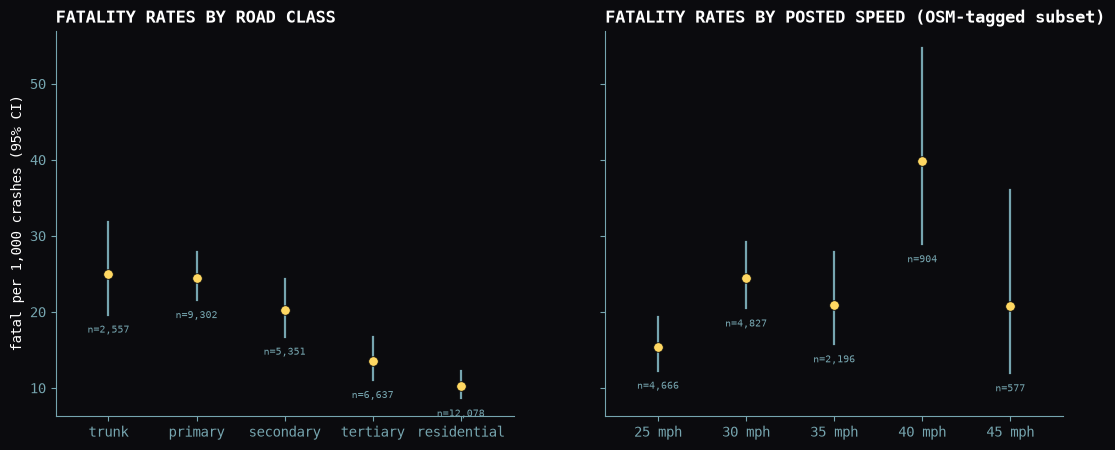

In [81]:
def wilson1k(k, n, z=1.96):
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return (c - h) * 1000, (c + h) * 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
order = ["trunk", "primary", "secondary", "tertiary", "residential"]
cls = by_class.loc[[o for o in order if o in by_class.index]].reset_index()
spd = sp[sp["crashes"] >= 100].reset_index()
spd["mph"] = spd["maxspeed"].str.extract(r"(\d+)").astype(int)
spd = spd.sort_values("mph").reset_index(drop=True)

for ax, df, lab, title in [
    (axes[0], cls, "hwy", "FATALITY RATES BY ROAD CLASS"),
        (axes[1], spd, "maxspeed", "FATALITY RATES BY POSTED SPEED (OSM-tagged subset)")]:
    for i, r in df.iterrows():
        lo, hi = wilson1k(r["fatal"], r["crashes"])
        ax.plot([i, i], [lo, hi], color=DIM, lw=1.6)
        ax.scatter(i, 1000 * r["fatal"] / r["crashes"], color=GOLD, s=48,
                   zorder=3, edgecolors=INK, linewidths=0.6)
        ax.annotate(f"n={int(r['crashes']):,}", (i, lo), xytext=(0, -13),
                    textcoords="offset points", ha="center", fontsize=7, color=DIM)
    ax.set_xticks(range(len(df)), df[lab])
    ax.set_title(title, loc="left")
    ax.set_xlim(-0.6, len(df) - 0.4)
axes[0].set_ylabel("fatal per 1,000 crashes (95% CI)")
fig.savefig(OUT / "severity_design_gradient.png", dpi=400, bbox_inches="tight")

In [82]:
keep_cols = ["name", "hwy", "crash_count", "fatal_cnt", "ksi_cnt",
             "long_snap_cnt", "crash_index", "fatal_index", "ksi_index",
             "hot_crash", "hot_fatal", "hot_ksi", "geometry"]
if "on_hin" in edges:
    keep_cols.insert(-1, "on_hin")
edges.loc[edges["crash_count"] > 0].to_crs(epsg=4326)[keep_cols] \
    .to_file(OUT / "crash_index_edges.geojson", driver="GeoJSON")
print("\nDone. Outputs in", OUT)


Done. Outputs in /Users/cyberhbliu/Desktop/PERSONAL/2026portfolio/crash/crash_outputs
